# Company 360: one issuer across every dataset

3spread families share identifiers, so you can walk everything the SEC
knows about one company: registry metadata, filing activity, insider
sentiment, institutional owners, 5%+ stakeholders, and pending insider
sales, all keyed by the same cik/ticker.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import datetime as dt

import pandas as pd

from py3spread import Client

TICKER = "AAPL"
client = Client()

cik = client.filings.list(ticker=TICKER, limit=1)["data"][0]["cik"]
profile = client.entities.get(cik)
{k: profile.get(k) for k in ["cik", "name", "sic", "sic_description",
                             "exchanges", "tickers", "state_of_incorporation"]}

{'cik': '320193',
 'name': 'Apple Inc.',
 'sic': '3571',
 'sic_description': 'Electronic Computers',
 'exchanges': ['Nasdaq'],
 'tickers': ['AAPL'],
 'state_of_incorporation': None}

## What does 3spread have on file

The coverage endpoint answers per family, useful in public beta before
assuming a gap.

In [2]:
cov = client.coverage.by_issuer(TICKER)
pd.DataFrame.from_dict(cov["families"], orient="index")

,filing_count,period_min,period_max,accepted_time_max
insiders,469,2021-01-04,2026-06-15,2026-06-17T00:00:00
proposed_sales,77,2023-04-06,2026-05-27,2026-05-27T00:00:00


## Filing activity, last 12 months

form_type
4           42
144         13
3            3
SC 13G/A     2
SC 13G       1
144/A        1


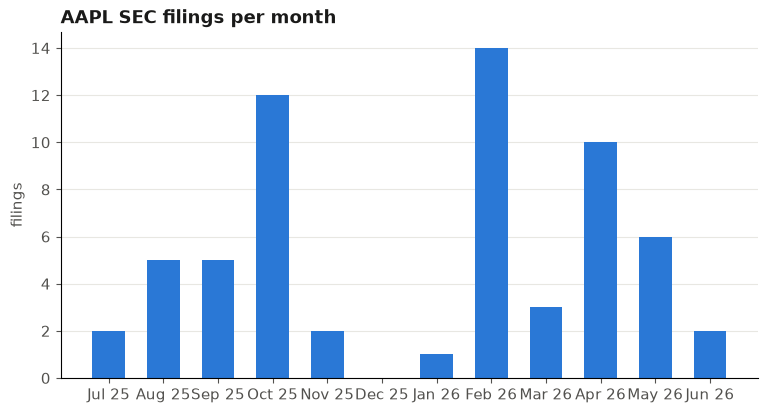

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
AQUA = "#1baf7a"
INK = "#52514e"


end = dt.date.today()
start = end - dt.timedelta(days=365)
filings = pd.DataFrame(client.filings.iter(
    ticker=TICKER, accepted_start=str(start), accepted_end=str(end)))
filings["accepted_time"] = pd.to_datetime(filings["accepted_time"])

print(filings["form_type"].value_counts().to_string())

monthly = filings.set_index("accepted_time").resample("MS").size()
fig, ax = plt.subplots()
ax.bar(monthly.index.strftime("%b %y"), monthly.values, color=BLUE, width=0.6)
ax.set_title(f"{TICKER} SEC filings per month", loc="left", fontweight="bold")
ax.set_ylabel("filings")
ax.grid(axis="x", visible=False)
plt.show()

## Insider sentiment, trailing 90 days

In [4]:
ratio = client.insiders.buy_sell_ratio(ticker=TICKER, window_days=90)
{k: ratio[k] for k in ["since", "until", "buys_count", "buys_dollars",
                       "sells_count", "sells_dollars", "buy_sell_ratio"]}

{'since': '2026-04-04',
 'until': '2026-07-03',
 'buys_count': 0,
 'buys_dollars': '0',
 'sells_count': 20,
 'sells_dollars': '187861894.2800000000000000',
 'buy_sell_ratio': 0}

## Largest institutional owners

The cusip comes from the company's beneficial ownership filings, one
family feeding a query into another.

In [5]:
bo = client.beneficial_ownership.list(ticker=TICKER, limit=1)["data"]
cusip = bo[0]["issuer_cusip"] if bo else None
print("cusip via 13D/G filings:", cusip)

holders = pd.DataFrame(client.institutional_holdings.holdings(
    cusip=cusip, period="2026-03-31", min_value=1_000_000_000,
    sort="value", order="desc", limit=8,
)["data"])
holders["value_usd"] = pd.to_numeric(holders["value_usd"])
holders[["filing_manager_name", "value_usd", "period_of_report"]].style.format(
    {"value_usd": "${:,.0f}"})

cusip via 13D/G filings: 037833100


,filing_manager_name,value_usd,period_of_report
0,VANGUARD CAPITAL MANAGEMENT LLC,"$242,076,924,860",2026-03-31
1,VANGUARD CAPITAL MANAGEMENT LLC,"$241,720,924,860",2026-03-31
2,STATE STREET CORP,"$152,868,226,190",2026-03-31
3,"BlackRock, Inc.","$107,584,293,761",2026-03-31
4,VANGUARD PORTFOLIO MANAGEMENT LLC,"$84,115,410,189",2026-03-31
5,"GEODE CAPITAL MANAGEMENT, LLC","$81,852,564,204",2026-03-31
6,"BlackRock, Inc.","$76,634,111,416",2026-03-31
7,FMR LLC,"$49,295,912,309",2026-03-31


## 5%+ stakeholders and pending insider sales

In [6]:
# ticker-filtered rows are issuer-side, so the actual stakeholders come
# from each filing's reporting persons
print("recent 13D/13G and who filed them:")
for f in client.beneficial_ownership.list(ticker=TICKER, limit=5)["data"]:
    det = client.beneficial_ownership.get(f["filing_id"])
    persons = ", ".join(p["names"] for p in det.get("reporting_persons") or [])
    kind = f.get("schedule_type") or f["form_type"]
    amended = " (amendment)" if f["is_amendment"] else ""
    print(f"  {f['accepted_time'][:10]}  {kind:<5} {persons or '(persons not parsed)'}{amended}")

sales = pd.DataFrame(client.proposed_sales.list(ticker=TICKER, limit=5)["data"])
cols = [c for c in ["accepted_time", "filer_name", "seller_name",
                    "aggregate_market_value"] if c in sales.columns]
print("\nrecent form 144 (proposed sales):")
print(sales[cols].to_string(index=False) if len(sales) else "none on file")

recent 13D/13G and who filed them:
  2026-04-29  13G   Vanguard Capital Management


  2026-03-26  13G   The Vanguard Group (amendment)
  2025-07-29  13G   The Vanguard Group (amendment)


  2024-02-14  13G   Warren E. Buffett, Berkshire Hathaway Inc, National Indemnity Company, GEICO Corporation, Government Employees Insurance Company, Columbia Insurance Company, Berkshire Hathaway Assurance Corporation, Finial Reinsurance Company, National Indemnity Company of the South, Berkshire Hathaway Specialty Insurance Company, National Fire & Marine Insurance Company, Redwood Fire & Casualty Insurance Company, National Indemnity Company of Mid America, Oak River Insurance Company, AmGUARD Insurance Company, Berkshire Hathaway Homestate Insurance Company, Berkshire Hathaway Direct Insurance Company, National Liability & Fire Insurance Company, Cypress Insurance Company, MedPro Group Inc, The Medical Protective Company, Princeton Insurance Company, Berkshire Hathaway Life Insurance Company of Nebraska, Old United Casualty Company, Old United Life Insurance Company, Mount Vernon Fire Insurance Company, Radnor Specialty Insurance Company, United States Liability Insurance Company, 

Every table above came from the same client with the same identifiers.
Point `TICKER` at anything with a cik and rerun.